In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    build_corr_matrix_option1,
    generate_env,
)
from tqdm import tqdm
from joblib import Parallel, delayed

# Tol colorblind-friendly palette
tol_bright = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
]

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
rho_sign_flipped = np.array([1.0, -0.6, 0.0, 0.6])
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])

# Define parameter grid to test
rho_lr_values = [0.05, 0.1, 0.3, 0.5, 0.7]
observation_noise_values = [0.1, 0.5, 1.0]

# Create conditions for each parameter combination
conditions = {}

# Add base conditions
conditions["perfectly_calibrated"] = {
    "label": "SG-ICM\ncalibrated",
    "params": {
        "rho_update_rule": None,
        "rho": rho_true,
        "model_type": "SG-ICM",
    }
}

conditions["asocial"] = {
    "label": "AS",
    "params": {
        "rho_update_rule": None,
        "rho": rho_zero,
        "model_type": "SG-ICM",
    }
}

# Add learning conditions for each parameter combination
update_conditions = []
for lr in rho_lr_values:
    for noise in observation_noise_values:
        condition_name = f"lr{lr}_noise{noise}"
        update_conditions.append(condition_name)
        conditions[condition_name] = {
            "label": f"SG-ICM learning\nlr={lr}, noise={noise}",
            "params": {
                "rho_update_rule": "landmarks_corr",
                "rho_update_kwargs": {"rho_lr": lr},
                "rho": rho_zero,
                "model_type": "SG-ICM",
                "rho_update_init": 0.0,
            },
            "rho_lr": lr,
            "observation_noise": noise,
        }

print(f"Testing {len(rho_lr_values)} learning rates: {rho_lr_values}")
print(f"Testing {len(observation_noise_values)} noise levels: {observation_noise_values}")
print(f"Total learning conditions: {len(update_conditions)}")
print(f"\nConditions to test:")
for cond in update_conditions:
    print(f"  - {cond}")

Testing 5 learning rates: [0.05, 0.1, 0.3, 0.5, 0.7]
Testing 3 noise levels: [0.1, 0.5, 1.0]
Total learning conditions: 15

Conditions to test:
  - lr0.05_noise0.1
  - lr0.05_noise0.5
  - lr0.05_noise1.0
  - lr0.1_noise0.1
  - lr0.1_noise0.5
  - lr0.1_noise1.0
  - lr0.3_noise0.1
  - lr0.3_noise0.5
  - lr0.3_noise1.0
  - lr0.5_noise0.1
  - lr0.5_noise0.5
  - lr0.5_noise1.0
  - lr0.7_noise0.1
  - lr0.7_noise0.5
  - lr0.7_noise1.0


In [3]:
def get_agent0_rho(model):
    agent = model.grid.agents[0]
    return np.array(agent.rho, dtype=float)

def run_condition(condition_name, condition_cfg, parent, child_maps, n_children, n_steps=15, seed=0):
    # Extract observation noise from condition config
    obs_noise = condition_cfg.get("observation_noise", 0.1)
    
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        rho_update_sigma_zeta=0.1,
        rho_update_basis="full",
        tau_sampling=True,
        beta_sampling=True,
        length_scale_sampling=True,
        observation_noise_private=obs_noise,
        seed=seed,
        **condition_cfg["params"]
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["seed"] = seed
    df["rho_lr"] = condition_cfg.get("rho_lr", None)
    df["observation_noise"] = obs_noise
    return df, np.array(rho_history)

def process_one_seed(env_seed, conditions, corr_matrix, n_children, grid_size, n_steps):
    local_results = []
    local_rhos = []

    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), corr_matrix, grid_size=grid_size)

    for condition_name, condition_cfg in conditions.items():
        df, rho_hist = run_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_children,
            n_steps=n_steps,
            seed=env_seed,
        )
        local_results.append(df)
        local_rhos.append(
            {
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "seed": env_seed,
                "rho_history": rho_hist,
                "rho_lr": condition_cfg.get("rho_lr", None),
                "observation_noise": condition_cfg.get("observation_noise", None),
            }
        )
    return local_results, local_rhos

In [4]:
n_envs = 30
n_steps = 30
grid_size = 11
n_children = corr_matrix.shape[0] - 1

print(f"Running {n_envs} simulations with {n_steps} steps each...")

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed)(seed, conditions, corr_matrix, n_children, grid_size, n_steps)
    for seed in tqdm(range(n_envs))
)

all_results = []
rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_results.extend(seed_dfs)
    rho_histories.extend(seed_rhos)

results = pd.concat(all_results, ignore_index=True)

Running 30 simulations with 30 steps each...


100%|██████████| 30/30 [00:16<00:00,  1.79it/s]
/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_77349/3358124842.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat(all_results, ignore_index=True)


Plotting 15 parameter combinations...



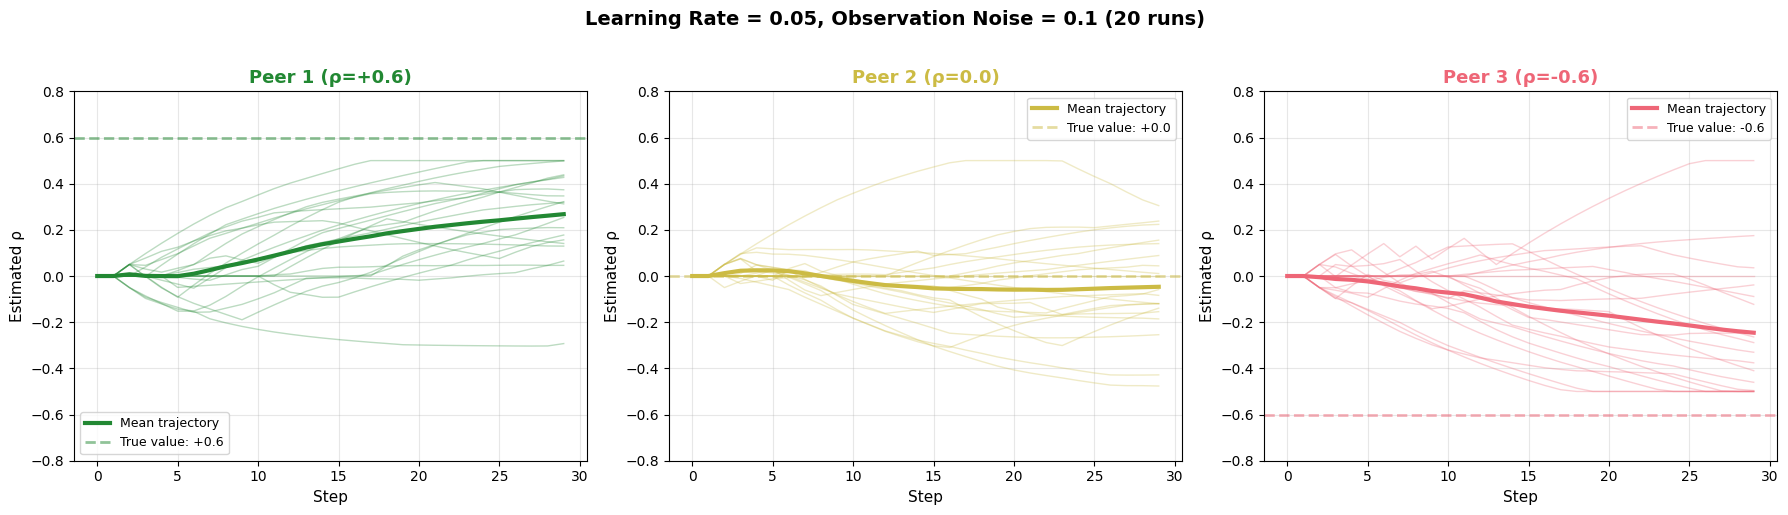

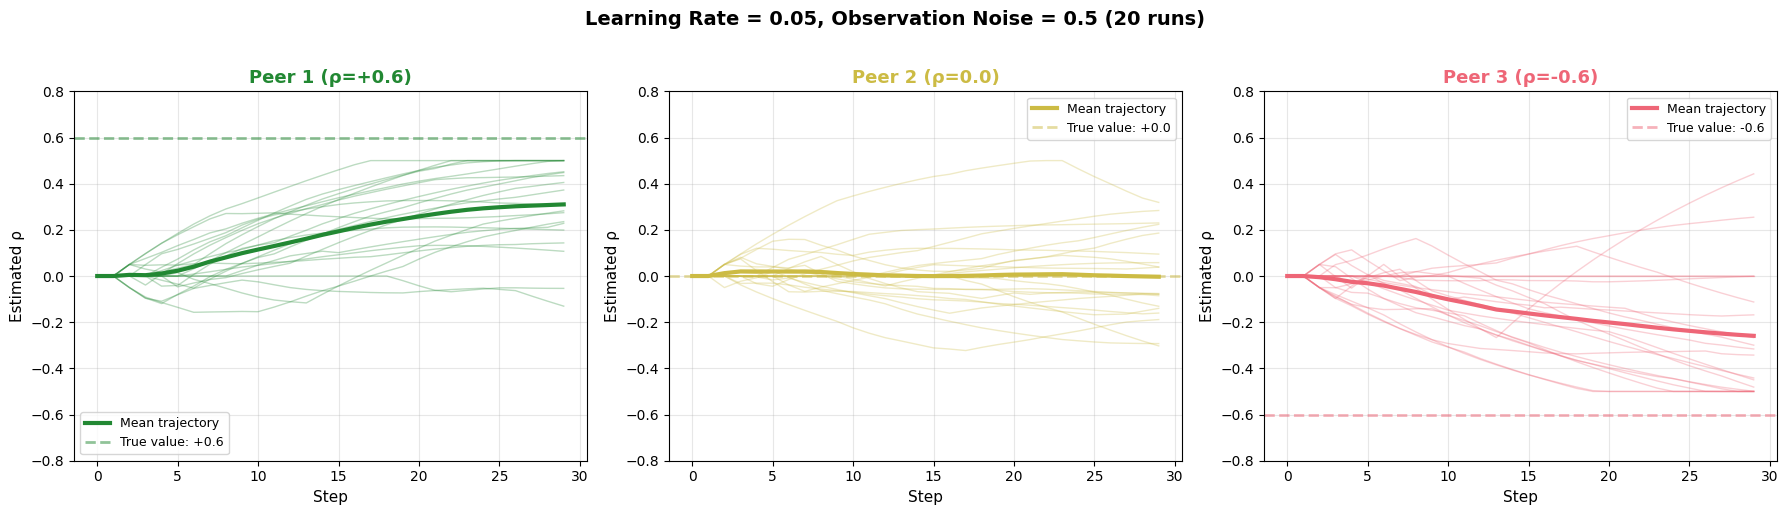

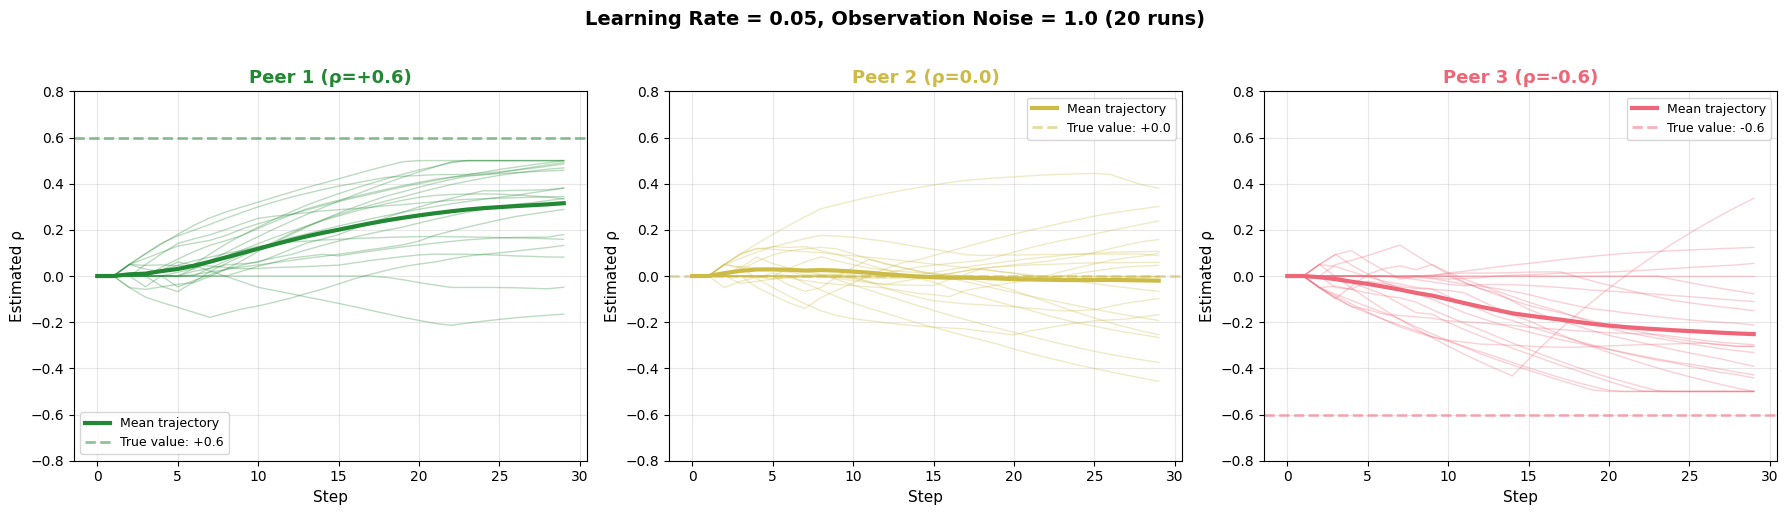

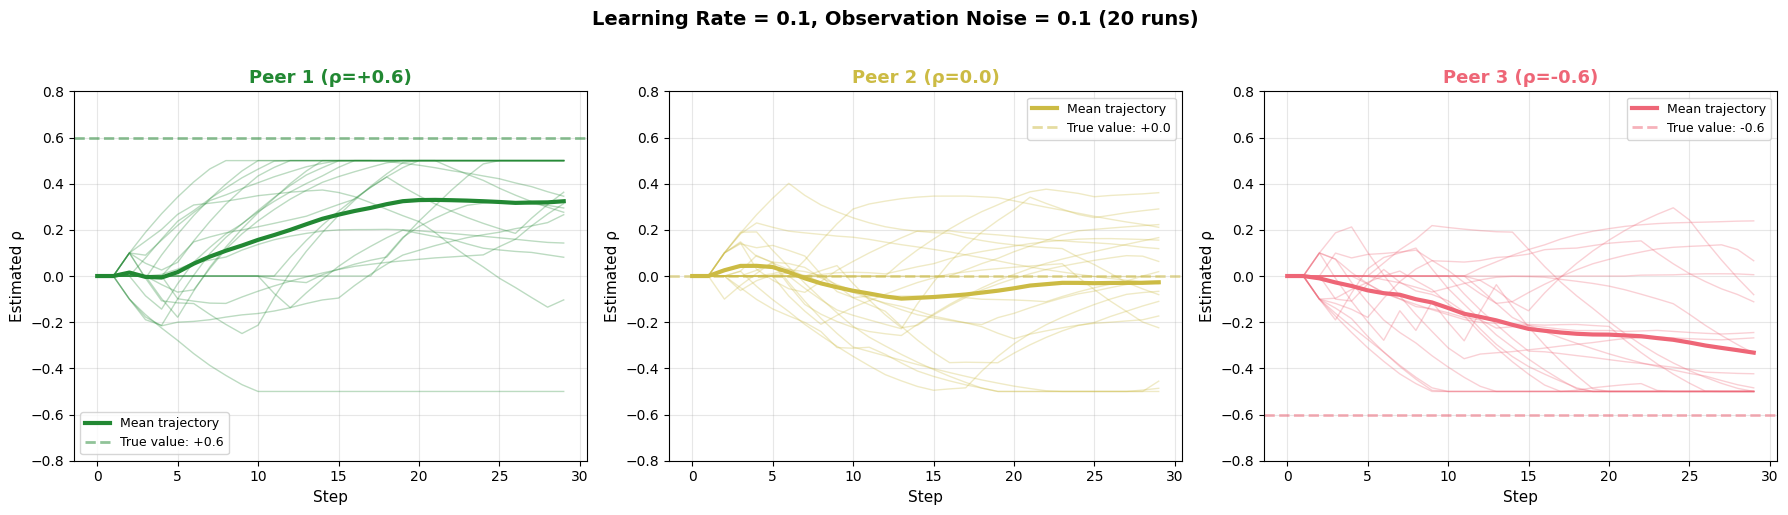

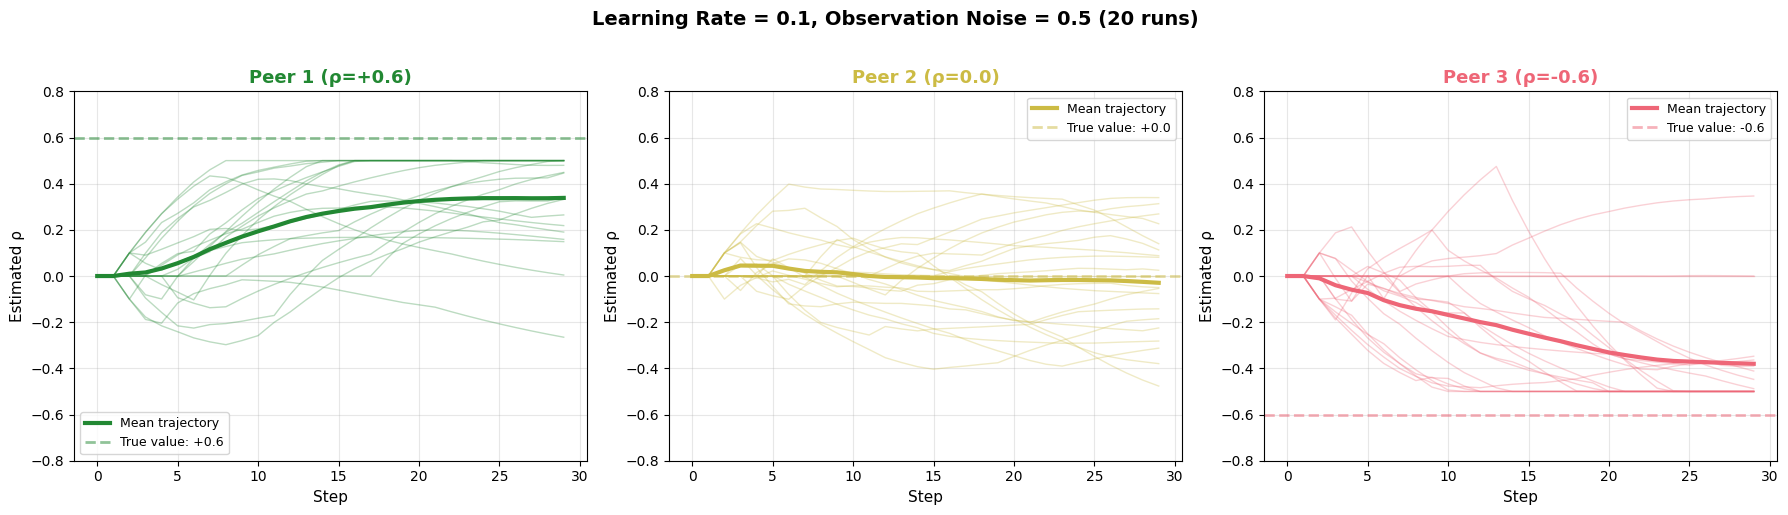

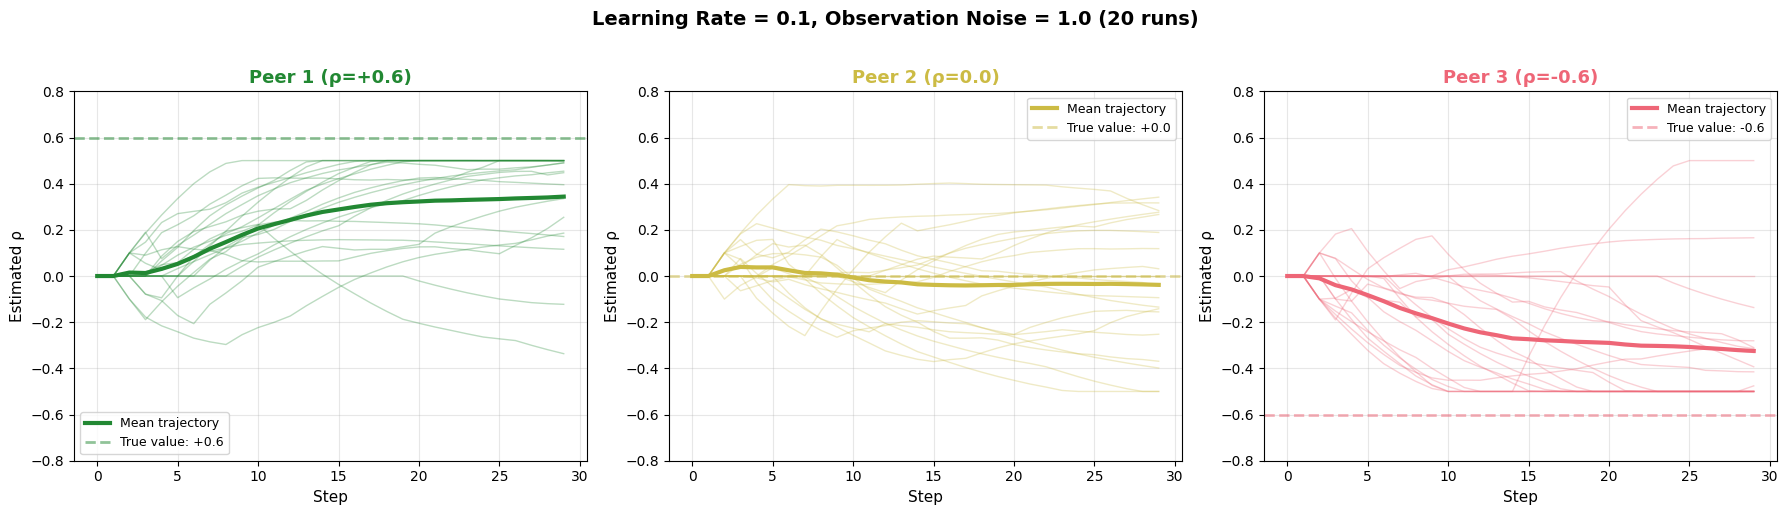

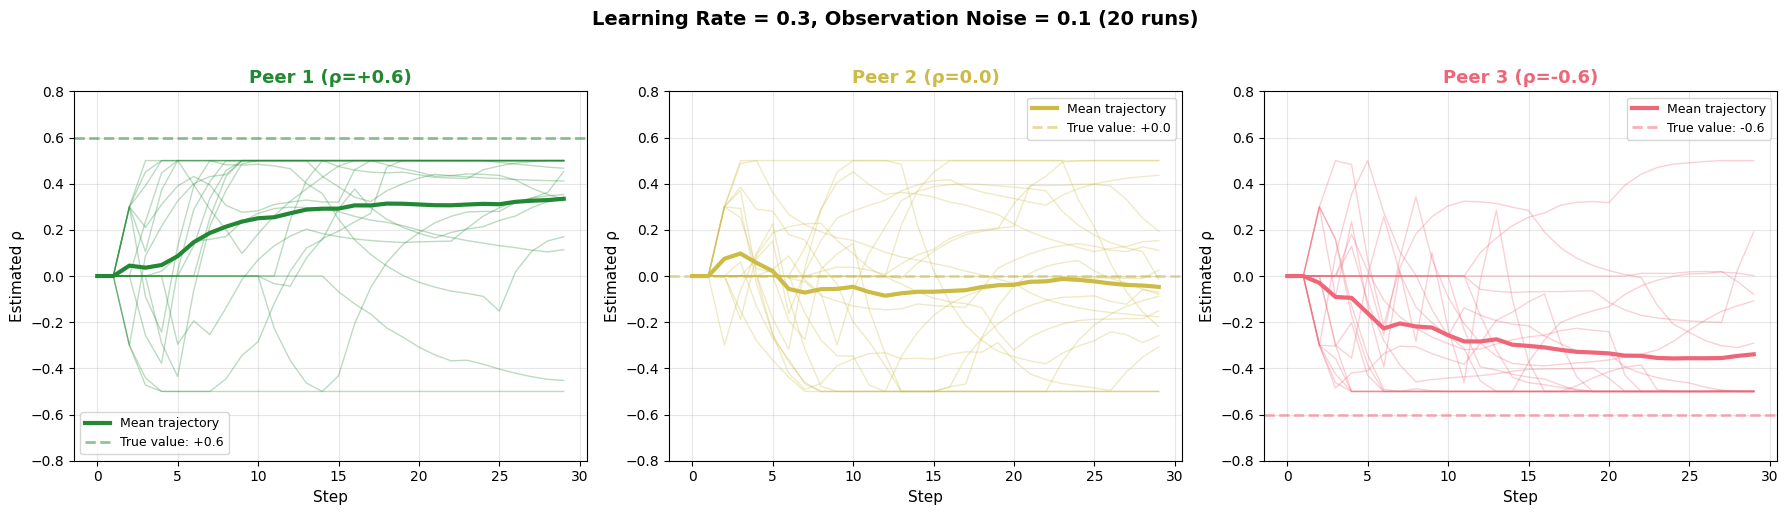

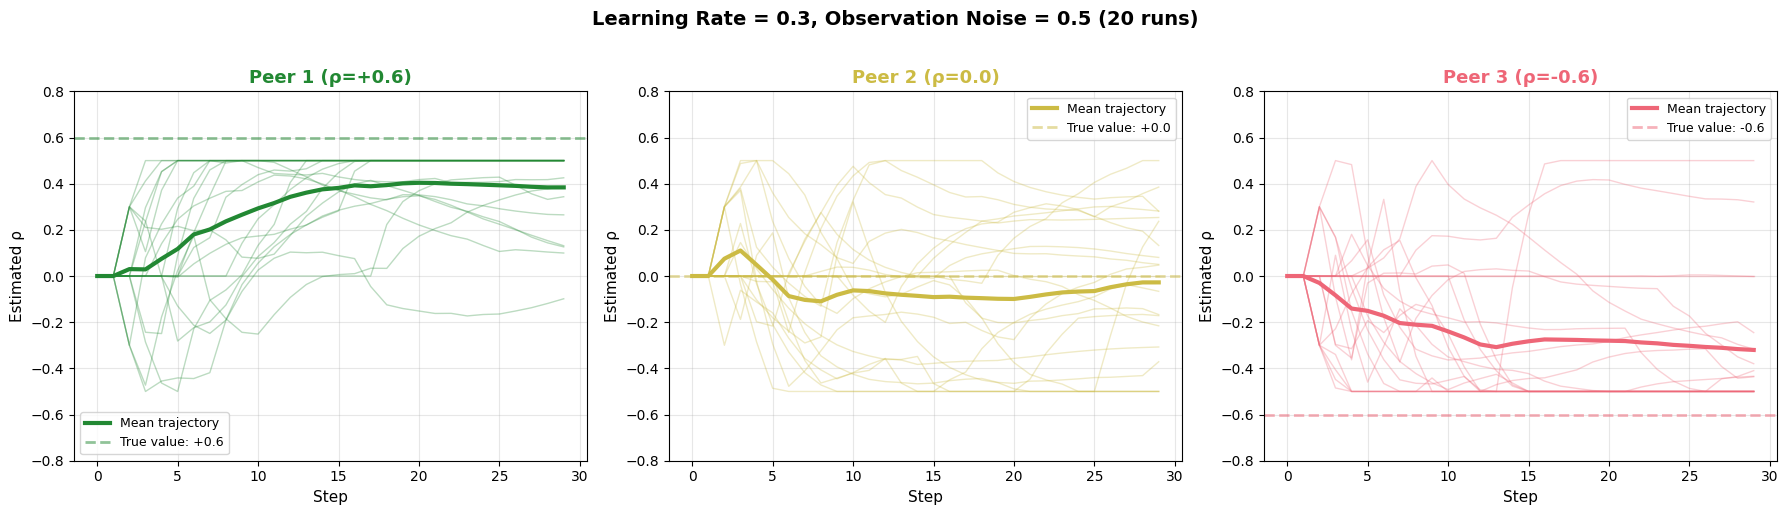

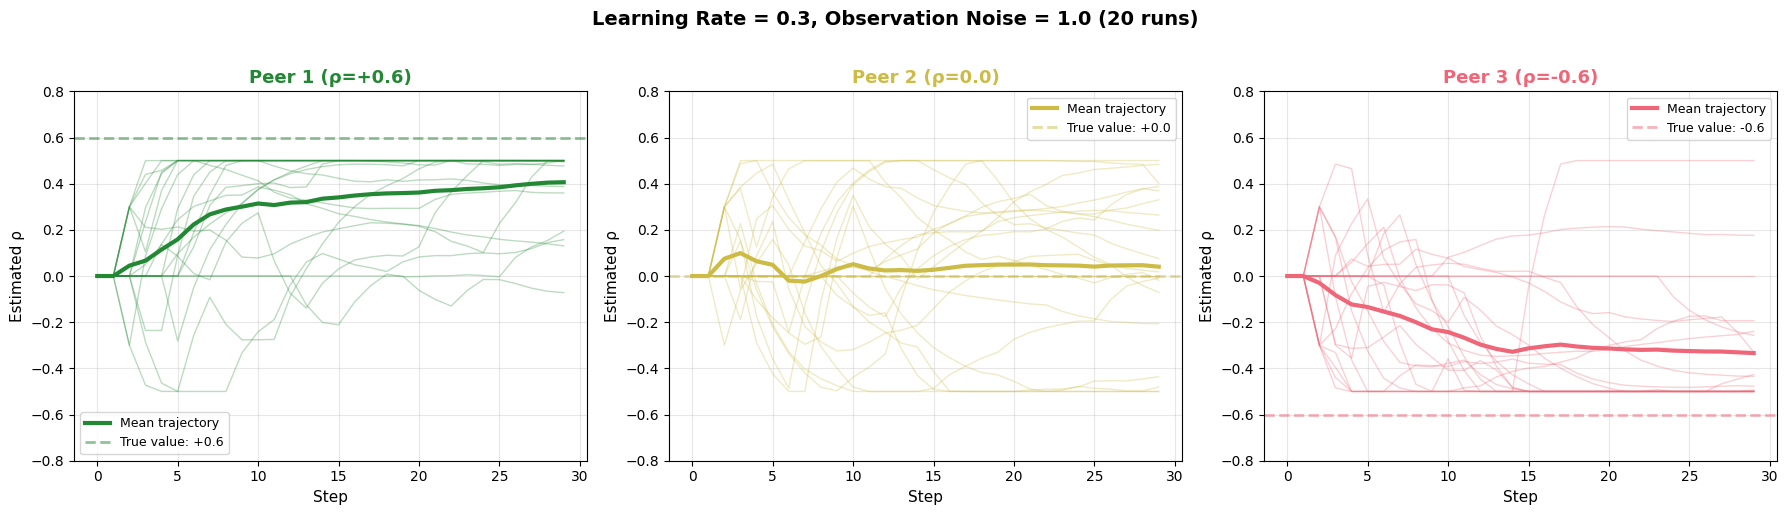

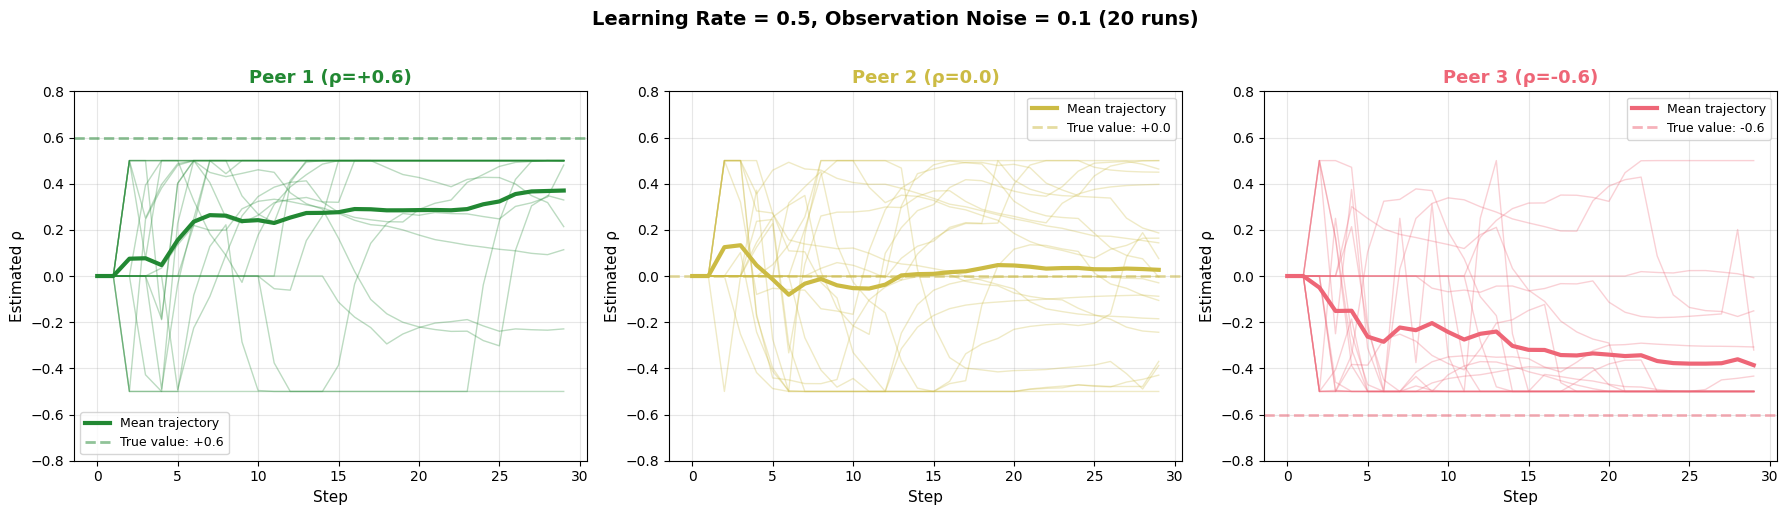

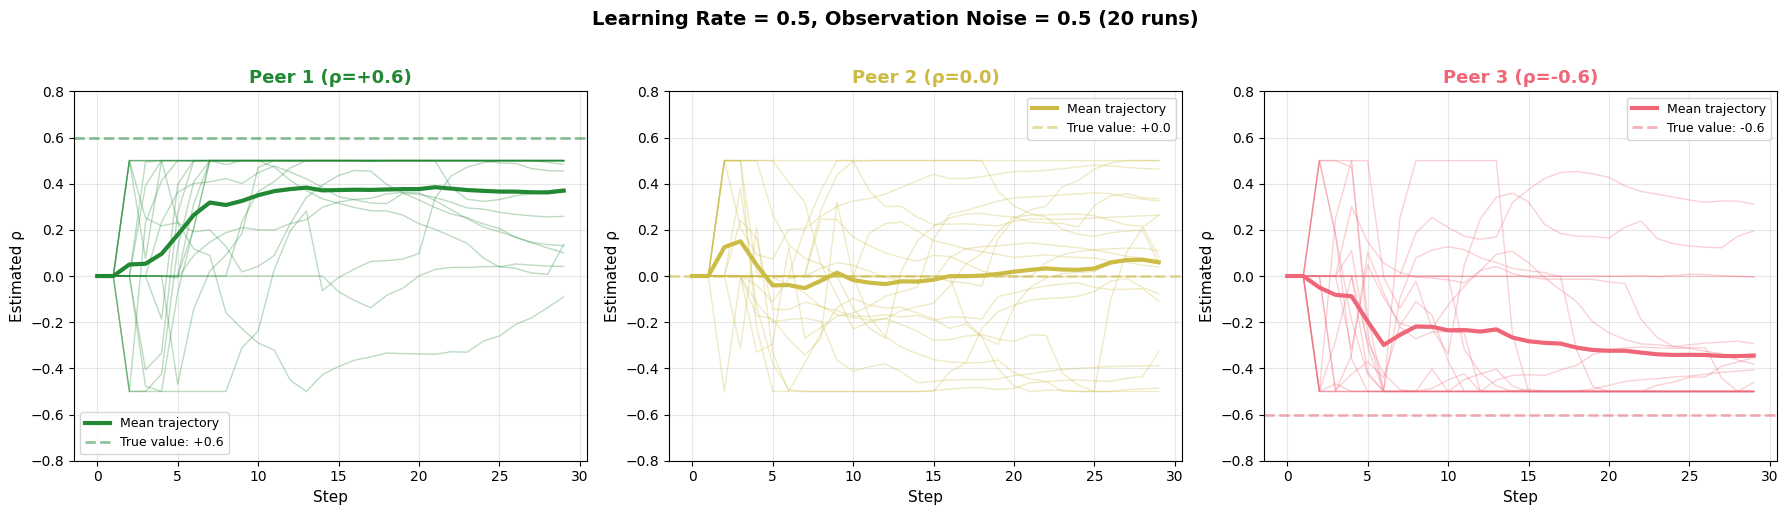

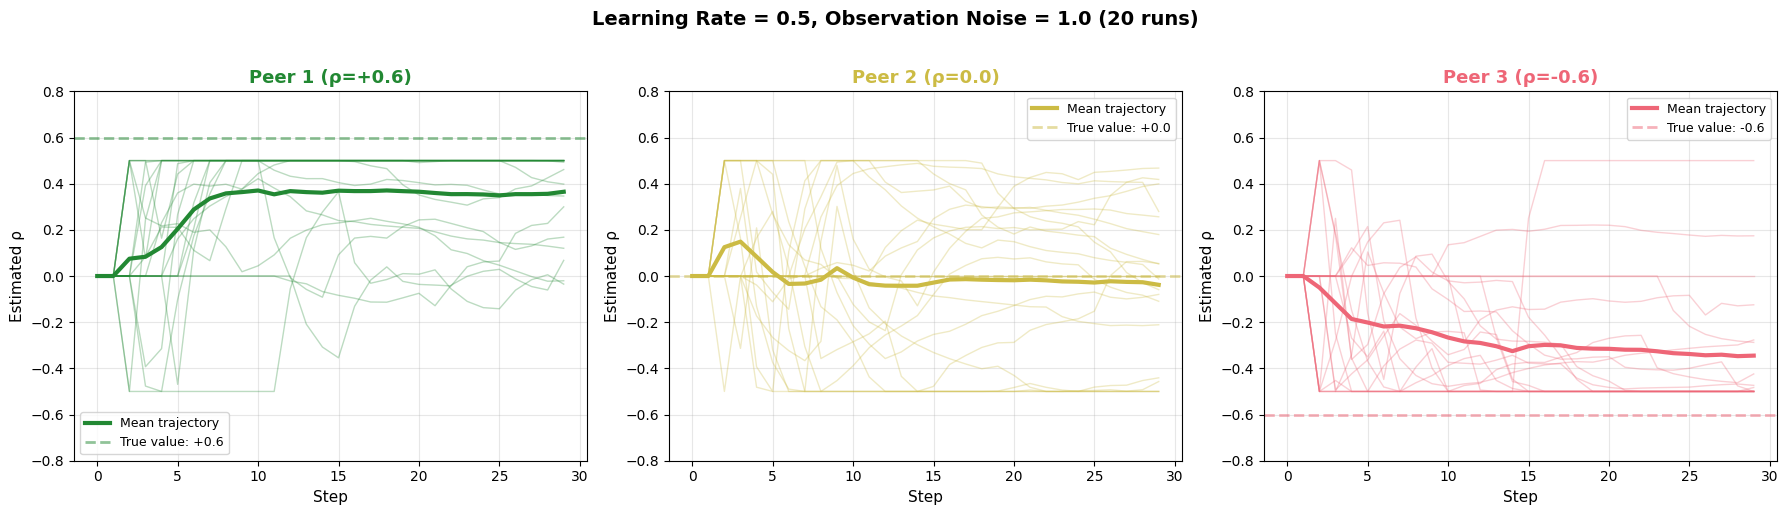

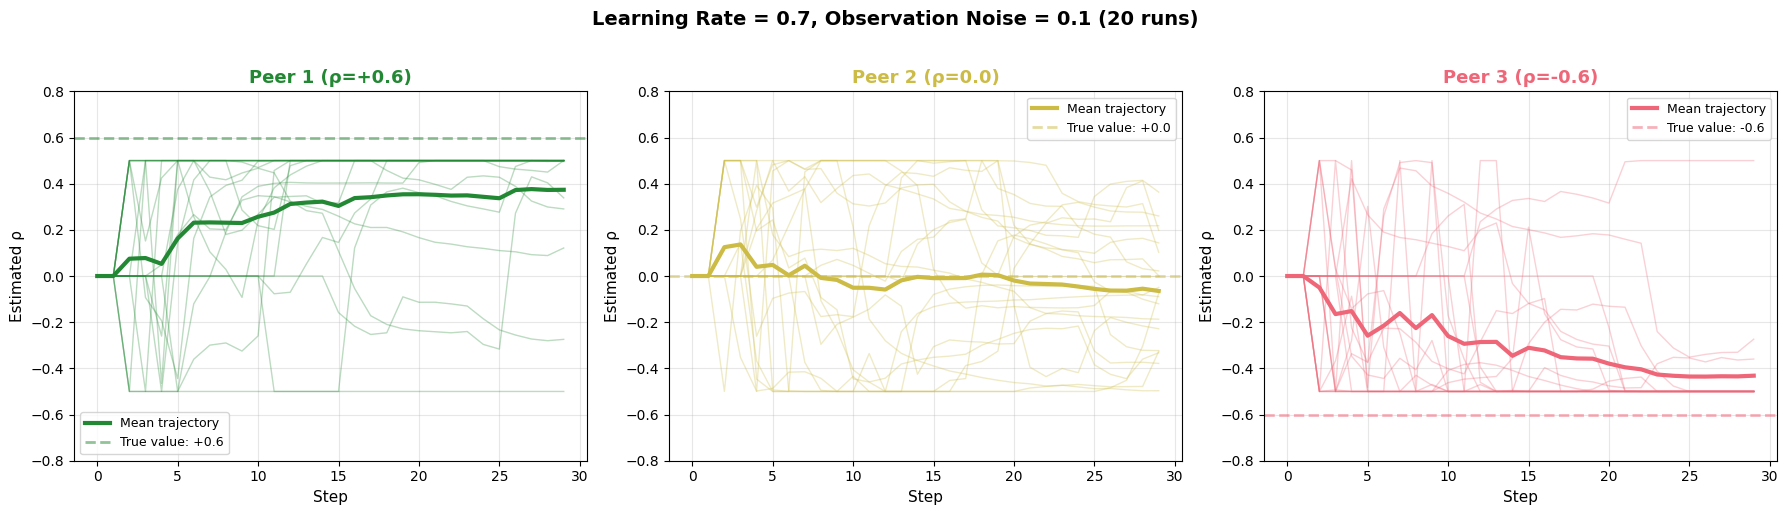

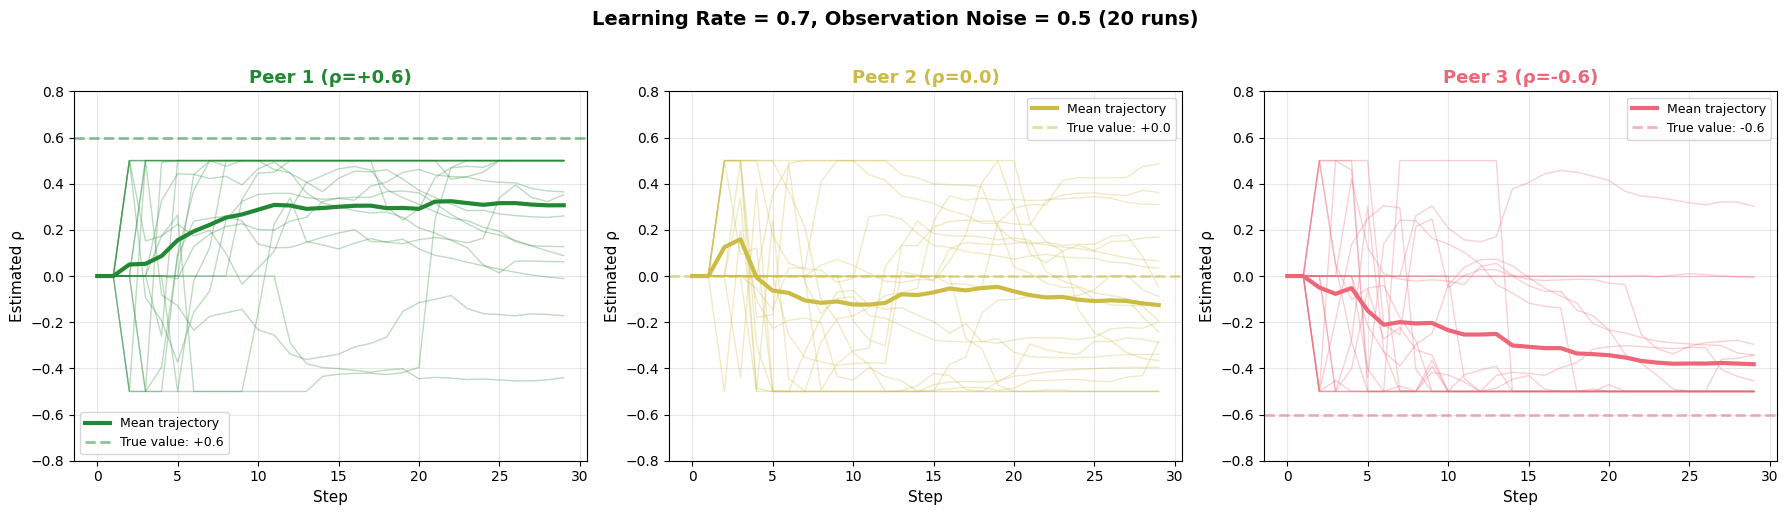

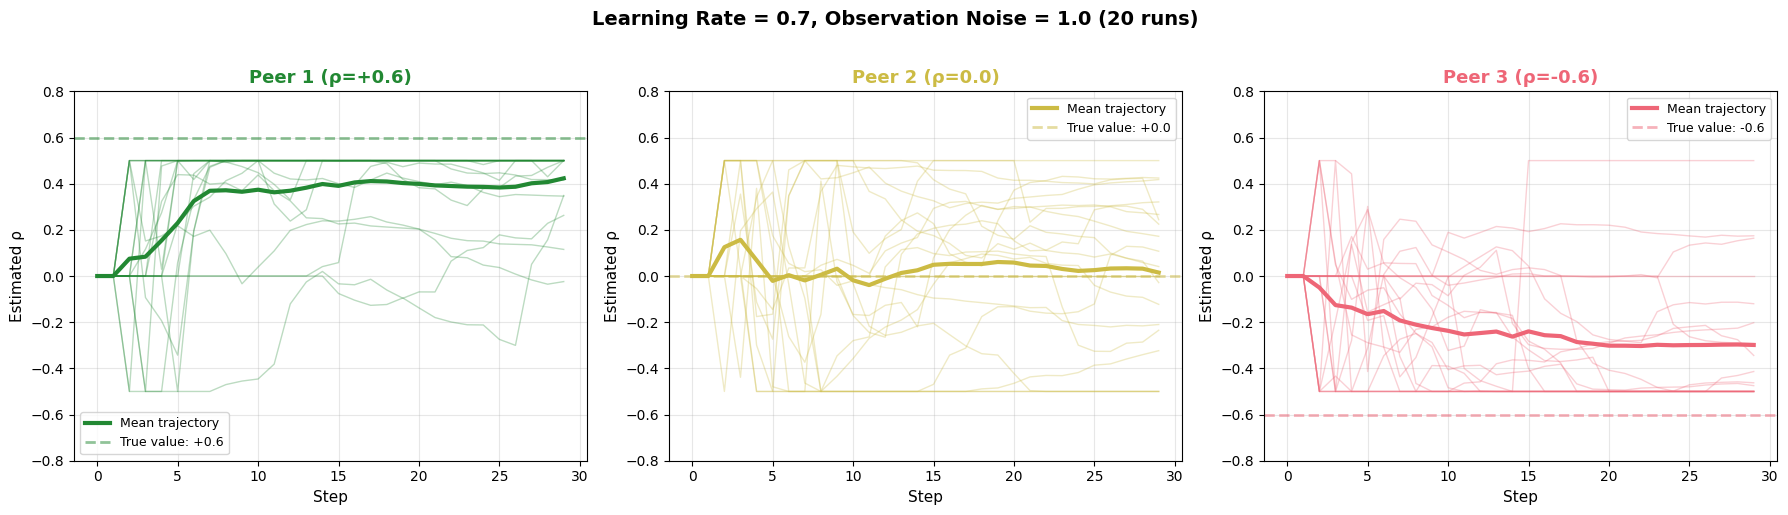

In [5]:
def plot_individual_rho_trajectories(rho_histories, conditions, update_conditions, rho_true, n_trajectories=20):
    """Plot individual rho learning curves to visualize fluctuations - one subplot per peer."""
    
    true_rho = rho_true[1:]
    peer_colors = ['#228833', '#CCBB44', '#EE6677']  # green, yellow, red
    peer_names = ['Peer 1 (ρ=+0.6)', 'Peer 2 (ρ=0.0)', 'Peer 3 (ρ=-0.6)']
    
    # Plot for each condition
    for condition in update_conditions:
        # Get trajectories for this condition
        trajectories = [
            entry["rho_history"]
            for entry in rho_histories
            if entry["condition"] == condition
        ][:n_trajectories]
        
        if not trajectories:
            continue
        
        # Get parameters for this condition
        lr = rho_histories[0].get("rho_lr", None) if rho_histories else None
        noise = rho_histories[0].get("observation_noise", None) if rho_histories else None
        
        # Extract lr and noise from condition name
        if "lr" in condition and "noise" in condition:
            parts = condition.split("_")
            lr_str = parts[0].replace("lr", "")
            noise_str = parts[1].replace("noise", "")
            try:
                lr = float(lr_str)
                noise = float(noise_str)
            except:
                pass
        
        # Create 3 subplots (one per peer)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot each peer in separate subplot
        for peer_idx, (ax, color, peer_name, true_val) in enumerate(zip(axes, peer_colors, peer_names, true_rho)):
            # Plot individual trajectories (thin, transparent lines)
            for traj in trajectories:
                ax.plot(traj[:, peer_idx + 1], color=color, alpha=0.3, linewidth=1.0)
            
            # Plot mean trajectory on top (thick line)
            mean_hist = np.mean(np.stack(trajectories, axis=0), axis=0)
            ax.plot(mean_hist[:, peer_idx + 1], color=color, linewidth=3, 
                   label=f'Mean trajectory', zorder=10)
            
            # True value line
            ax.axhline(true_val, linestyle='--', color=color, alpha=0.5, linewidth=2,
                      label=f'True value: {true_val:+.1f}')
            
            ax.set_title(peer_name, fontsize=13, fontweight='bold', color=color)
            ax.set_xlabel("Step", fontsize=11)
            ax.set_ylabel("Estimated ρ", fontsize=11)
            ax.legend(loc="best", fontsize=9)
            ax.grid(alpha=0.3)
            ax.set_ylim([true_rho.min() - 0.2, true_rho.max() + 0.2])
        
        # Title with parameters
        if lr is not None and noise is not None:
            title = f"Learning Rate = {lr}, Observation Noise = {noise} ({len(trajectories)} runs)"
        else:
            title = f"Individual Learning Trajectories - {len(trajectories)} runs"
        
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# Plot individual trajectories for all conditions
print(f"Plotting {len(update_conditions)} parameter combinations...\n")
plot_individual_rho_trajectories(rho_histories, conditions, update_conditions, rho_true, n_trajectories=20)

In [6]:
def analyze_fluctuations(rho_histories, conditions, update_conditions, rho_true):
    """Compute statistics about fluctuations in rho estimates for each parameter combination."""
    
    true_rho = rho_true[1:]
    
    print("="*80)
    print("FLUCTUATION ANALYSIS FOR ALL PARAMETER COMBINATIONS")
    print("="*80)
    
    for condition in update_conditions:
        trajectories = [
            entry["rho_history"][:, 1:]  # Exclude first column (always 1.0)
            for entry in rho_histories
            if entry["condition"] == condition
        ]
        
        if not trajectories:
            continue
        
        trajectories = np.stack(trajectories, axis=0)  # Shape: (n_runs, n_steps, n_peers)
        
        # Extract lr and noise from condition name
        lr = None
        noise = None
        if "lr" in condition and "noise" in condition:
            parts = condition.split("_")
            lr_str = parts[0].replace("lr", "")
            noise_str = parts[1].replace("noise", "")
            try:
                lr = float(lr_str)
                noise = float(noise_str)
            except:
                pass
        
        print(f"\n{'='*80}")
        print(f"Learning Rate = {lr}, Observation Noise = {noise}")
        print(f"{'='*80}")
        
        # Final values
        final_values = trajectories[:, -1, :]  # Shape: (n_runs, n_peers)
        
        print(f"\nFinal ρ estimates (step {trajectories.shape[1]}):")
        for peer_idx in range(len(true_rho)):
            mean_final = final_values[:, peer_idx].mean()
            std_final = final_values[:, peer_idx].std()
            true_val = true_rho[peer_idx]
            bias = mean_final - true_val
            print(f"  Peer {peer_idx+1}: {mean_final:+.3f} ± {std_final:.3f} (true: {true_val:+.1f}, bias: {bias:+.3f})")
        
        # Step-to-step changes (measure of fluctuation)
        step_changes = np.abs(np.diff(trajectories, axis=1))  # Shape: (n_runs, n_steps-1, n_peers)
        
        print(f"\nStep-to-step fluctuations (mean absolute change):")
        for peer_idx in range(len(true_rho)):
            mean_change = step_changes[:, :, peer_idx].mean()
            max_change = step_changes[:, :, peer_idx].max()
            print(f"  Peer {peer_idx+1}: mean={mean_change:.4f}, max={max_change:.4f}")
        
        # Overall MAE from true values across all steps
        errors = np.abs(trajectories - true_rho[np.newaxis, np.newaxis, :])  # Broadcasting
        mae_all = errors.mean(axis=(0, 1))  # Average across runs and steps
        mae_final = np.abs(final_values - true_rho[np.newaxis, :]).mean(axis=0)
        
        print(f"\nMean Absolute Error:")
        print(f"  Overall (all steps): {mae_all.mean():.4f}")
        print(f"  Final step only: {mae_final.mean():.4f}")
        for peer_idx in range(len(true_rho)):
            print(f"    Peer {peer_idx+1}: overall={mae_all[peer_idx]:.4f}, final={mae_final[peer_idx]:.4f}")

print("\nAnalyzing fluctuations for all parameter combinations...\n")
analyze_fluctuations(rho_histories, conditions, update_conditions, rho_true)


Analyzing fluctuations for all parameter combinations...

FLUCTUATION ANALYSIS FOR ALL PARAMETER COMBINATIONS

Learning Rate = 0.05, Observation Noise = 0.1

Final ρ estimates (step 30):
  Peer 1: +0.307 ± 0.180 (true: +0.6, bias: -0.293)
  Peer 2: -0.068 ± 0.198 (true: +0.0, bias: -0.068)
  Peer 3: -0.264 ± 0.268 (true: -0.6, bias: +0.336)

Step-to-step fluctuations (mean absolute change):
  Peer 1: mean=0.0154, max=0.0526
  Peer 2: mean=0.0124, max=0.0535
  Peer 3: mean=0.0168, max=0.0593

Mean Absolute Error:
  Overall (all steps): 0.3426
  Final step only: 0.2679
    Peer 1: overall=0.4421, final=0.2925
    Peer 2: overall=0.1052, final=0.1754
    Peer 3: overall=0.4804, final=0.3357

Learning Rate = 0.05, Observation Noise = 0.5

Final ρ estimates (step 30):
  Peer 1: +0.289 ± 0.190 (true: +0.6, bias: -0.311)
  Peer 2: +0.024 ± 0.188 (true: +0.0, bias: +0.024)
  Peer 3: -0.263 ± 0.240 (true: -0.6, bias: +0.337)

Step-to-step fluctuations (mean absolute change):
  Peer 1: mean=0.0

REWARD PERFORMANCE SUMMARY (sorted by mean final cumulative reward)
 rho_lr  observation_noise      mean      std      min       max
   0.10                1.0 19.239723 4.745697 9.117518 29.487262
   0.50                1.0 19.175761 4.740438 9.117518 29.558459
   0.70                1.0 19.139663 4.713540 9.117518 29.558459
   0.30                1.0 19.080687 4.705046 9.117518 29.487262
   0.05                1.0 19.019266 4.670487 9.117518 29.398054
   0.10                0.5 19.004461 4.372416 9.316262 29.487262
   0.05                0.5 18.991604 4.492337 9.316262 29.451964
   0.30                0.5 18.959861 4.335267 9.316262 29.558459
   0.50                0.5 18.954190 4.381713 9.316262 29.629657
   0.70                0.5 18.944947 4.393343 9.316262 29.629657
   0.05                0.1 18.786978 4.481464 9.118524 29.396582
   0.30                0.1 18.779469 4.418900 9.118524 29.396582
   0.70                0.1 18.778149 4.420950 9.118524 29.396582
   0.50               

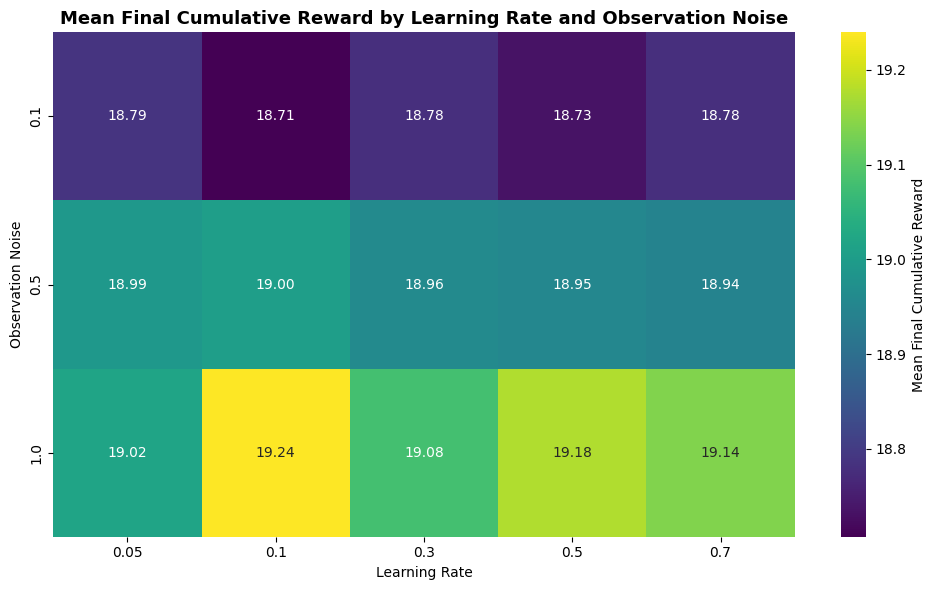


BEST:  lr=0.1, noise=1.0 -> reward=19.24 ± 4.75
WORST: lr=0.1, noise=0.1 -> reward=18.71 ± 4.39
Difference: 0.53


In [7]:
# Compare rewards across all parameter combinations
learning_results = results[results['condition'].str.contains('lr')].copy()

# Calculate final rewards for each combination
final_step = learning_results.groupby(['condition', 'seed'])['Step'].transform('max')
final_data = learning_results[learning_results['Step'] == final_step].copy()

# Summary statistics
summary = final_data.groupby(['rho_lr', 'observation_noise'])['cumulative_reward'].agg(['mean', 'std', 'min', 'max']).reset_index()
summary = summary.sort_values('mean', ascending=False)

print("="*80)
print("REWARD PERFORMANCE SUMMARY (sorted by mean final cumulative reward)")
print("="*80)
print(summary.to_string(index=False))

# Plot heatmap of mean rewards
pivot = summary.pivot(index='observation_noise', columns='rho_lr', values='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Mean Final Cumulative Reward'})
plt.title('Mean Final Cumulative Reward by Learning Rate and Observation Noise', fontsize=13, fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Observation Noise')
plt.tight_layout()
plt.show()

# Plot best vs worst conditions
best_cond = summary.iloc[0]
worst_cond = summary.iloc[-1]

print(f"\n{'='*80}")
print(f"BEST:  lr={best_cond['rho_lr']}, noise={best_cond['observation_noise']} -> reward={best_cond['mean']:.2f} ± {best_cond['std']:.2f}")
print(f"WORST: lr={worst_cond['rho_lr']}, noise={worst_cond['observation_noise']} -> reward={worst_cond['mean']:.2f} ± {worst_cond['std']:.2f}")
print(f"Difference: {best_cond['mean'] - worst_cond['mean']:.2f}")
print(f"{'='*80}")